<a href="https://colab.research.google.com/github/evelyn-oliveira26/Treinamento_em_IA/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/dataset titanic

/content/drive/MyDrive/dataset titanic


Primeiras Linhas:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500 

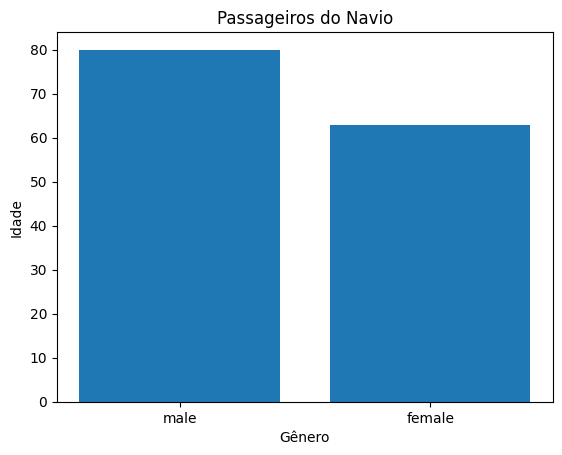

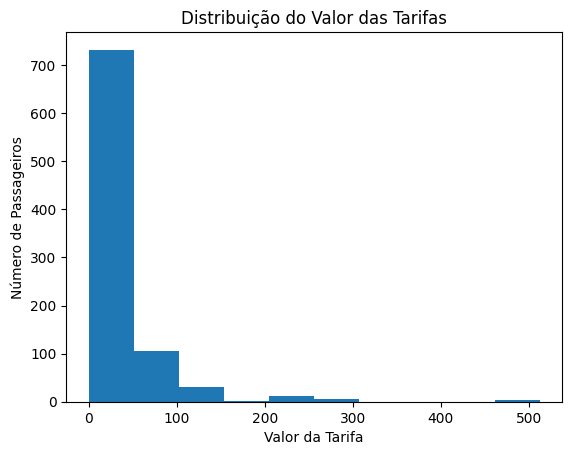

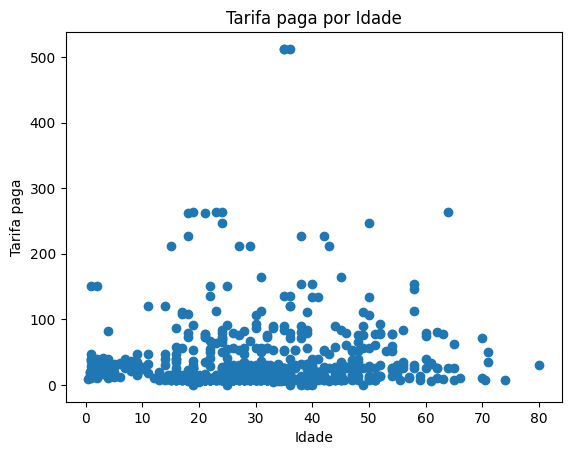

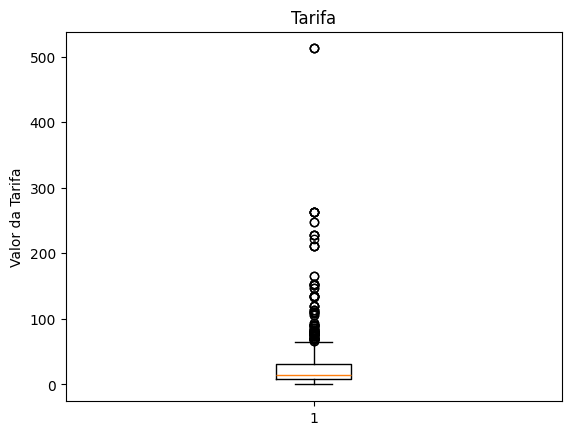

          Survived       Age
Survived  1.000000 -0.077221
Age      -0.077221  1.000000


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df_titanic = pd.read_csv(url)

print("Primeiras Linhas:\n", df_titanic.head())
print("\nTamanho:", df_titanic.shape)
print("\nColunas:\n", df_titanic.columns)
print("\nInformações:", df_titanic.info())
print("\nValores Ausentes:\n", df_titanic.isnull().sum())
print("\nPorcentagem de Valores Ausentes:\n", df_titanic.isnull().mean() * 100)
print("\nDuplicatas:", df_titanic.duplicated().sum())
print("\nEstatísticas Descritivas:\n", df_titanic.describe())

print("\nDistribuição dos Sexos:")
print(df_titanic["Sex"].value_counts().sort_index())

print("\nMédia das Classes com Tarifa:")
print(df_titanic.groupby("Pclass")["Fare"].mean())

#barras
plt.bar(df_titanic["Sex"], df_titanic["Age"])
plt.xlabel("Gênero")
plt.ylabel("Idade")
plt.title("Passageiros do Navio")
plt.show()

#histograma
plt.hist(df_titanic["Fare"])
plt.xlabel("Valor da Tarifa")
plt.ylabel("Número de Passageiros")
plt.title("Distribuição do Valor das Tarifas")
plt.show()

#dispersão
plt.scatter(df_titanic["Age"], df_titanic["Fare"])
plt.xlabel("Idade")
plt.ylabel("Tarifa paga")
plt.title("Tarifa paga por Idade")
plt.show()

#boxplot
plt.boxplot(df_titanic["Fare"])
plt.ylabel("Valor da Tarifa")
plt.title("Tarifa")
plt.show()

print(df_titanic[["Survived", "Age"]].corr())

**Tratamento dos valores ausentes:** A coluna "Age" (Idade) possui valores ausentes. Como não é possível saber com certeza a idade dos passageiros que não possuem esse dado, essas linhas foram removidas do dataset (comando abaixo). Apesar da remoção de 177 registros, o dataset ainda possui uma quantidade considerável de dados para a análise, passando de 891 para 714 registros. Assim, trabalhamos apenas com os registros que possuem a idade informada, mantendo os dados disponíveis para a análise.

In [6]:
#tratamento
df_titanic = df_titanic.dropna(subset=["Age"])

In [7]:
#após o tratamento
print("\nValores Ausentes:\n", df_titanic.isnull().sum())


Valores Ausentes:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64


**Insight 1:** A quantidade de passageiros do sexo masculino é maior do que a de passageiros do sexo feminino, com 577 homens e 314 mulheres. Isso mostra que os dois grupos não estão distribuídos igualmente no dataset, havendo uma predominância de passageiros do sexo masculino.

**Insight 2:** A tarifa média varia de acordo com a classe do passageiro, sendo de aproximadamente 84,15 na primeira classe, 20,66 na segunda e 13,68 na terceira. Isso indica que a classe estava diretamente relacionada ao valor pago pela passagem, com passageiros da primeira classe pagando valores maiores.

**Insight 3:** O histograma mostra que a maior parte dos passageiros está concentrada nas faixas de tarifas mais baixas, enquanto uma quantidade menor de passageiros pagou valores muito elevados. Isso indica que os valores das tarifas não estão distribuídos de maneira uniforme, existindo uma concentração de passageiros pagando valores baixos e alguns casos com tarifas muito acima da maioria.

**Insight 4:** A partir do gráfico de dispersão, podemos observar que não existe um padrão claro entre idade e tarifa, pois os pontos não apresentam uma tendência definida de crescimento ou redução conforme a idade aumenta. Dessa forma, não é possível estabelecer uma relação significativa entre essas duas variáveis, indicando que a idade, isoladamente, não explica o valor da tarifa paga pelos passageiros.

**Insight 5:** A correlação entre idade e sobrevivência é negativa. Isso indica que existe pouca relação entre essas duas variáveis, ou seja, a idade, por si só, não apresenta uma influência significativa sobre a sobrevivência dos passageiros. Dessa forma, outros fatores podem ter sido mais relevantes para determinar a sobrevivência.